# Fuel Prices analysis after WAR

## Data Cleaning

In [74]:
import pandas as pd
import numpy as np

### Importing fuel dataset for over february, march and april

In [75]:
df_1 = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\data cleaning\War impact on fuel price\FuelWatchRetail-02-2026.csv")
df_2 = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\data cleaning\War impact on fuel price\FuelWatchRetail-03-2026.csv")
df_3 = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\data cleaning\War impact on fuel price\FuelWatchRetail-04-2026.csv")

### Concatinating the three months dataset into one

In [76]:
df =  pd.concat([df_1, df_2, df_3], ignore_index=True)

### Formating the date time format

In [77]:
df['PUBLISH_DATE'] = pd.to_datetime(df['PUBLISH_DATE'], format='%d/%m/%Y')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221381 entries, 0 to 221380
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   PUBLISH_DATE         221381 non-null  datetime64[ns]
 1   TRADING_NAME         221381 non-null  object        
 2   BRAND_DESCRIPTION    221381 non-null  object        
 3   PRODUCT_DESCRIPTION  221381 non-null  object        
 4   PRODUCT_PRICE        221381 non-null  float64       
 5   ADDRESS              221381 non-null  object        
 6   LOCATION             221381 non-null  object        
 7   POSTCODE             221381 non-null  int64         
 8   AREA_DESCRIPTION     221381 non-null  object        
 9   REGION_DESCRIPTION   221381 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 16.9+ MB


### Selecting the day only after the day war started

In [94]:
df = df[(df['PUBLISH_DATE'] >= '2026-02-27') & (df['PUBLISH_DATE'] <= '2026-04-19')]

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147403 entries, 73978 to 221380
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   PUBLISH_DATE         147403 non-null  datetime64[ns]
 1   TRADING_NAME         147403 non-null  object        
 2   BRAND_DESCRIPTION    147403 non-null  object        
 3   PRODUCT_DESCRIPTION  147403 non-null  object        
 4   PRODUCT_PRICE        147403 non-null  float64       
 5   ADDRESS              147403 non-null  object        
 6   LOCATION             147403 non-null  object        
 7   POSTCODE             147403 non-null  int64         
 8   AREA_DESCRIPTION     147403 non-null  object        
 9   REGION_DESCRIPTION   147403 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 16.4+ MB


In [96]:
df.describe()

,PUBLISH_DATE,PRODUCT_PRICE,POSTCODE
count,147403,147403.000000,147403.000000
mean,2026-03-24 11:09:49.836027648,246.488467,6198.037665
min,2026-02-27 00:00:00,129.900000,6000.000000
25%,2026-03-11 00:00:00,215.900000,6065.000000
50%,2026-03-24 00:00:00,245.900000,6154.000000
75%,2026-04-06 00:00:00,277.400000,6237.000000
max,2026-04-19 00:00:00,397.300000,6765.000000
std,NaN,44.450572,183.277552


In [97]:
df_1.isnull().sum()

PUBLISH_DATE           0
TRADING_NAME           0
BRAND_DESCRIPTION      0
PRODUCT_DESCRIPTION    0
PRODUCT_PRICE          0
ADDRESS                0
LOCATION               0
POSTCODE               0
AREA_DESCRIPTION       0
REGION_DESCRIPTION     0
dtype: int64

### The dataset is clean so we can now start on EDA and visualizaton

In [83]:
import matplotlib.pyplot as plt

In [84]:
df["PRODUCT_DESCRIPTION"].unique()

array(['ULP', 'Diesel', '98 RON', 'PULP', 'Brand Diesel', 'LPG', 'E85'],
      dtype=object)

### Overall Rise in fuel price after the declaration of the war

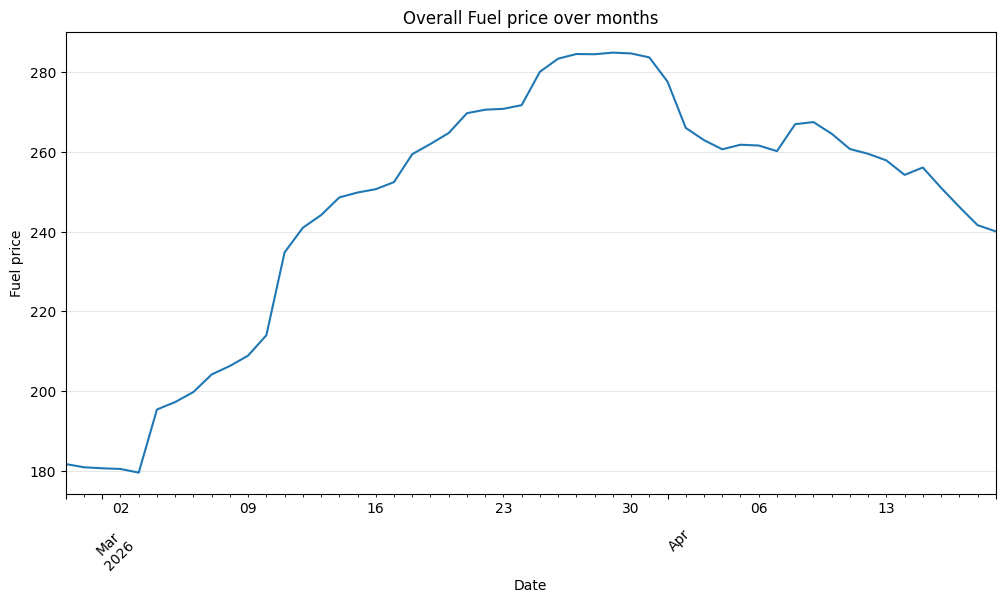

In [ ]:
fuel_price_rate =  df.groupby(df['PUBLISH_DATE'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='line')
plt.title('Overall Fuel price over months')
plt.xlabel('Date')
plt.ylabel('Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


### Line graph for ULP

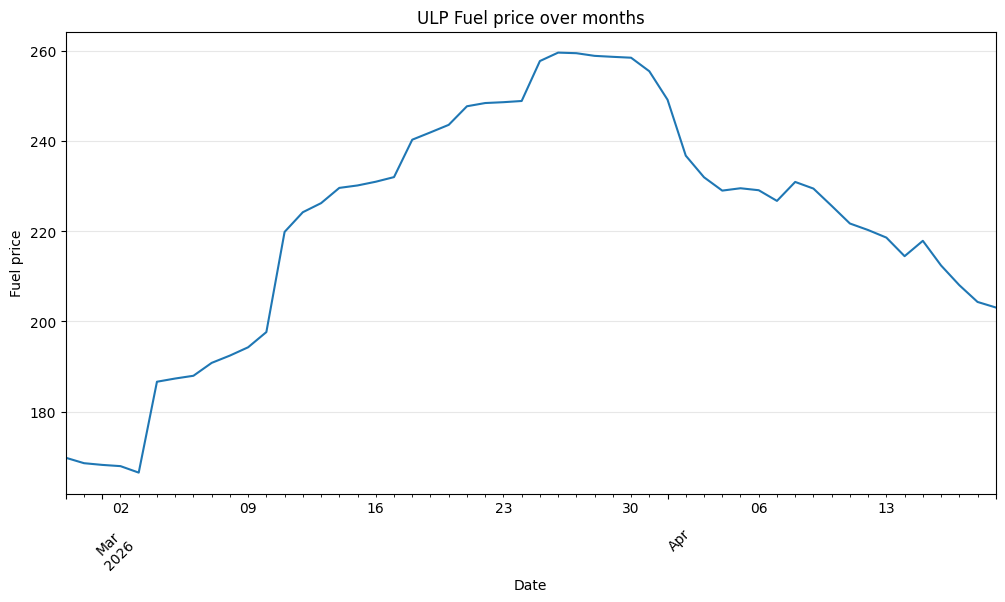

In [86]:
ulp_df = df[df['PRODUCT_DESCRIPTION']=='ULP']
fuel_price_rate =  ulp_df.groupby(df['PUBLISH_DATE'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='line')
plt.title('ULP Fuel price over months')
plt.xlabel('Date')
plt.ylabel('Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Diesel price line graph

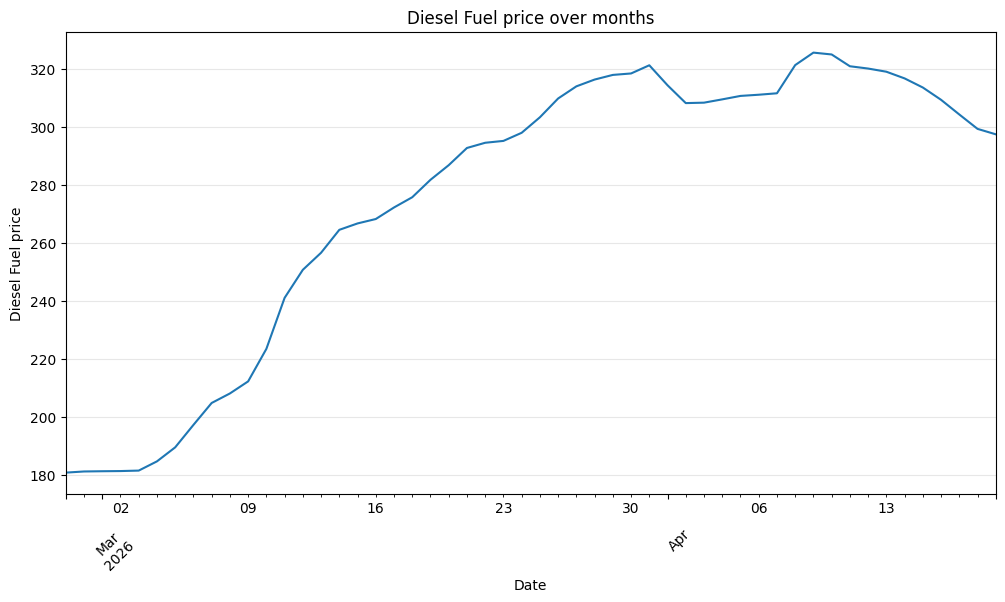

In [ ]:
ulp_df = df[df['PRODUCT_DESCRIPTION']=='Diesel']
fuel_price_rate =  ulp_df.groupby(df['PUBLISH_DATE'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='line')
plt.title('Diesel Fuel price over months')
plt.xlabel('Date')
plt.ylabel('Diesel Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


### PULP price Line Graph

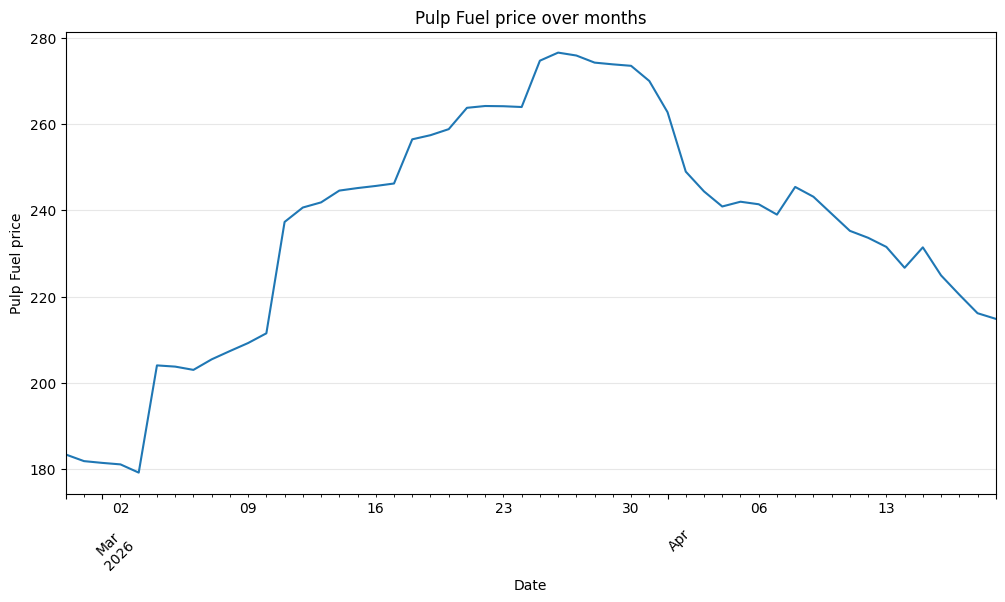

In [88]:
ulp_df = df[df['PRODUCT_DESCRIPTION']=='PULP']
fuel_price_rate =  ulp_df.groupby(df['PUBLISH_DATE'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='line')
plt.title('Pulp Fuel price over months')
plt.xlabel('Date')
plt.ylabel('Pulp Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### 98 RON Price Line Graph

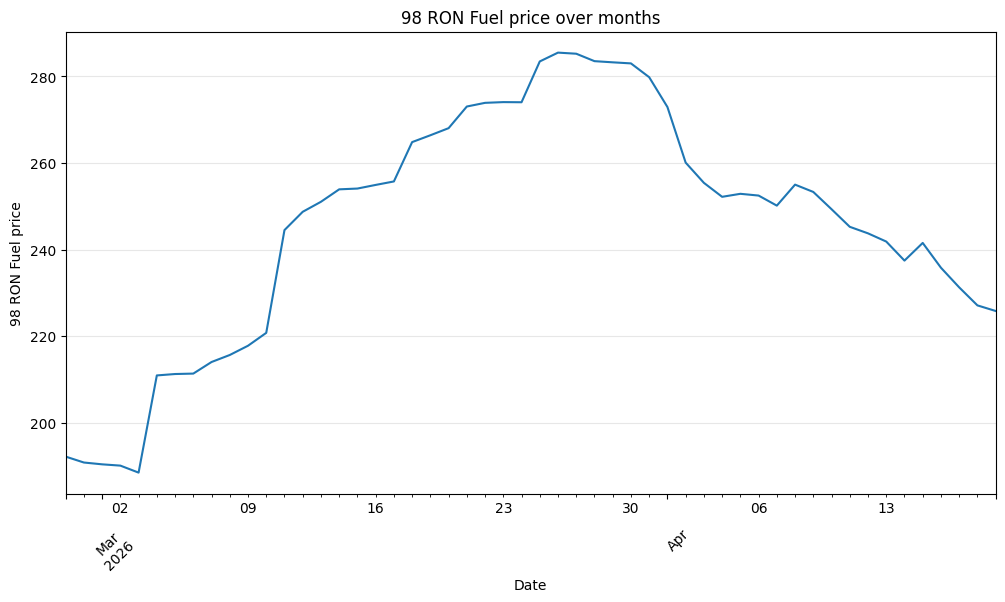

In [89]:
ulp_df = df[df['PRODUCT_DESCRIPTION']=='98 RON']
fuel_price_rate =  ulp_df.groupby(df['PUBLISH_DATE'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='line')
plt.title('98 RON Fuel price over months')
plt.xlabel('Date')
plt.ylabel('98 RON Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Brand Diesel Price Line Graph

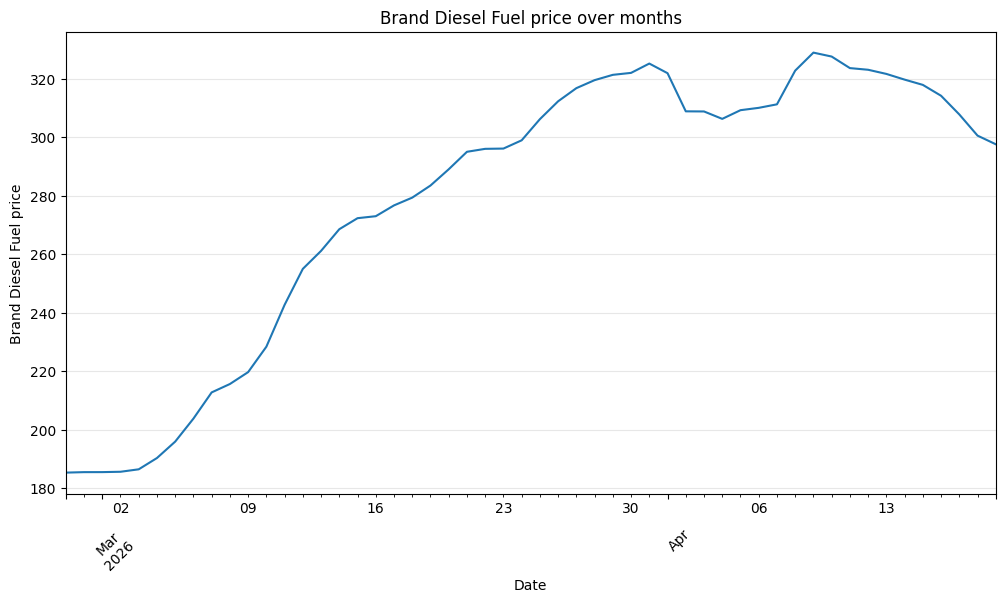

In [90]:
ulp_df = df[df['PRODUCT_DESCRIPTION']=='Brand Diesel']
fuel_price_rate =  ulp_df.groupby(df['PUBLISH_DATE'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='line')
plt.title('Brand Diesel Fuel price over months')
plt.xlabel('Date')
plt.ylabel('Brand Diesel Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### LPG Price Line Graph

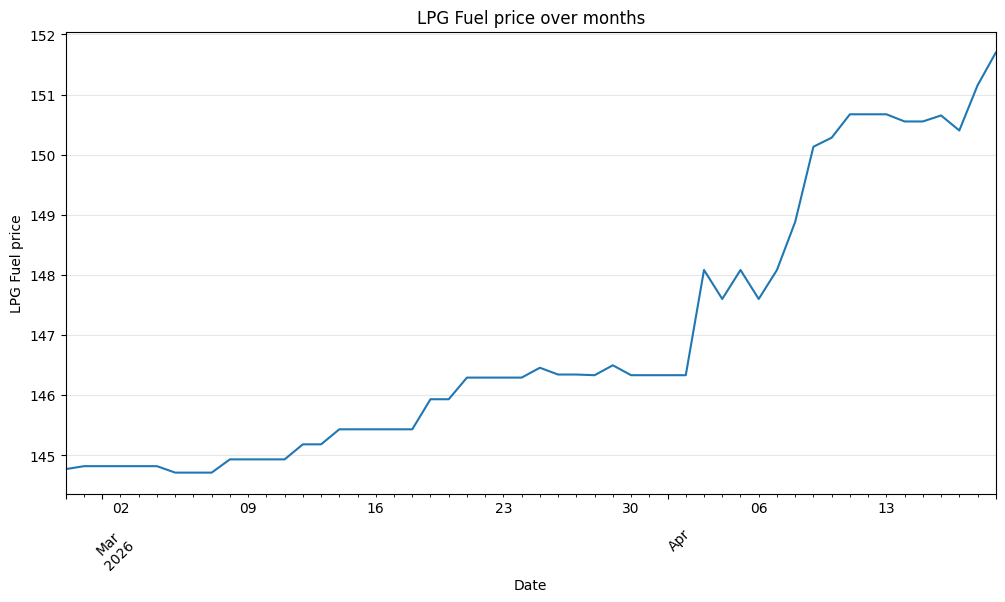

In [ ]:
ulp_df = df[df['PRODUCT_DESCRIPTION']=='LPG']
fuel_price_rate =  ulp_df.groupby(df['PUBLISH_DATE'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='line')
plt.title('LPG Fuel price over months')
plt.xlabel('Date')
plt.ylabel('LPG Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### E85 Price Line Graph

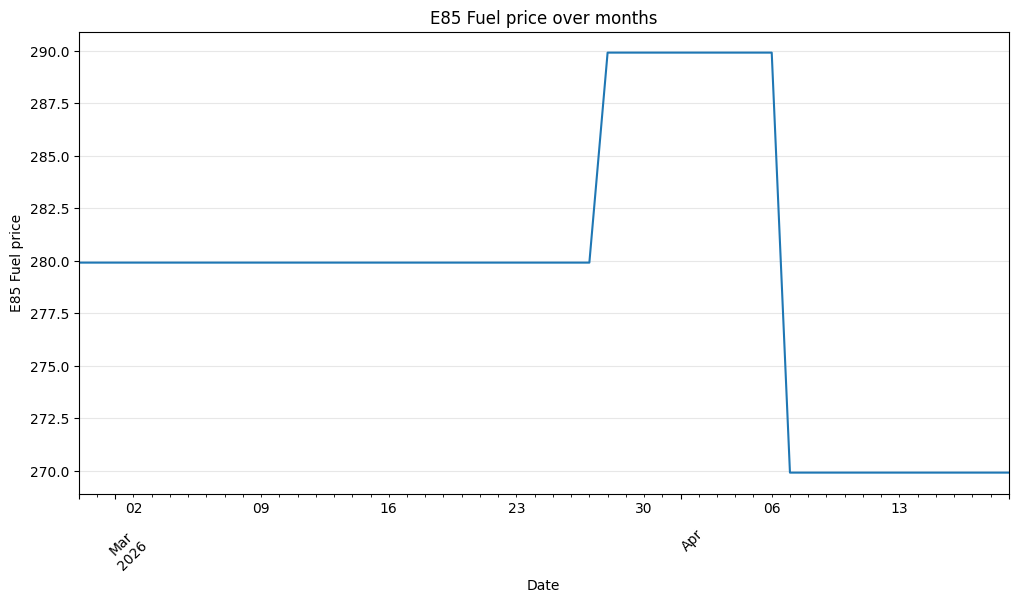

In [92]:
ulp_df = df[df['PRODUCT_DESCRIPTION']=='E85']
fuel_price_rate =  ulp_df.groupby(df['PUBLISH_DATE'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='line')
plt.title('E85 Fuel price over months')
plt.xlabel('Date')
plt.ylabel('E85 Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Price Comparision by Fuel Type

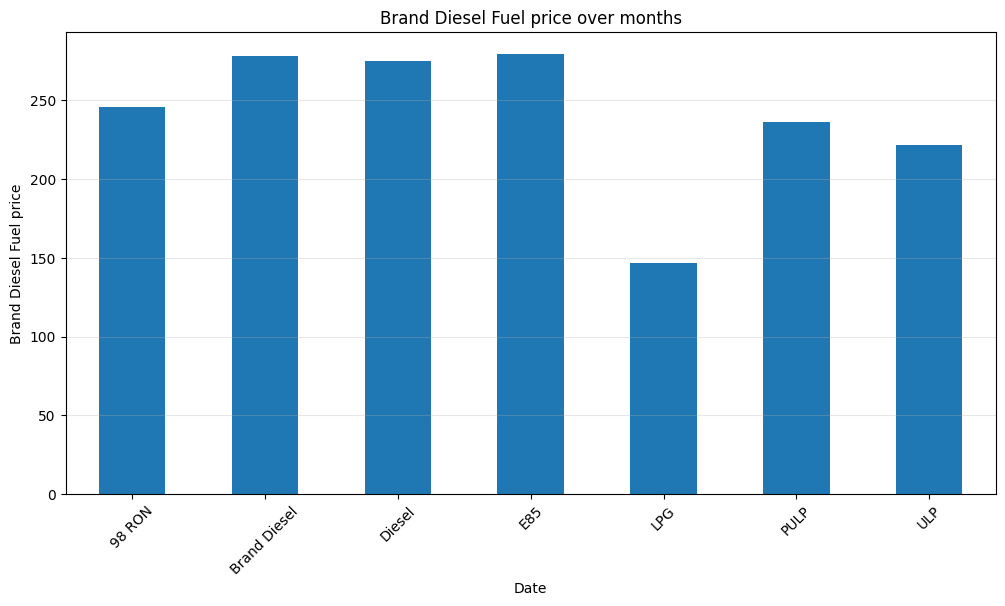

In [93]:

fuel_price_rate =df.groupby(df['PRODUCT_DESCRIPTION'])['PRODUCT_PRICE'].mean()

plt.figure(figsize=(12,6))
fuel_price_rate.plot(kind='bar')
plt.title('Brand Diesel Fuel price over months')
plt.xlabel('Date')
plt.ylabel('Brand Diesel Fuel price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Executive Summary

### Timeline

1. 27th february- War started
2. 28th February- Iranian Supreme Leader Killed
3. 9th March- Strait of Hermuz became sensative
4. 


## Effect on Fuel Price